In [1]:
from firedrake import *

In [8]:
import matplotlib.pyplot as plt
# Plot functions using Firedrake's built-in plotting functions
def plot_function(fn):
    fig, axes = plt.subplots()
    colors = tripcolor(fn, axes=axes) # or tricontour
    fig.colorbar(colors)
    plt.show()

In [ ]:
### Hierarchy of elements ###

# 1. Mesh: geometric domain subdivided into elements
omega = UnitSquareMesh(2,2)

# 2. Function Space: some finite-dimensional function space in a Sobolev space
P1CG = FunctionSpace(omega, 'CG', 1)
P2CG = FunctionSpace(omega, 'CG', 2)

# 3. Function: a function of a given finite element space
w = Function(P2CG)
print(w.dat.data[:]) # get the basis coefficients

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


Note: At this stage w does not yet represent a concrete function; it is initialised as the trivial field (the 0 function).

In [4]:
u = interpolate(w, P1CG) # the interpolant of w in the P1CG space, returns a Function

A more precise way of writing the interpolation operation is to explicitly pass the dual object into the second slot

Since I: U -> V can be expressed equivalently as the bilinear form I: UxV^* -> R, we pass the dual object as an argument placed in slot 0 i.e., a `TestFunction`

`interpolate` returns a symbolic expression for the interpolation. Mathematically it corresponds to evaluating the dofs of CG1 at the function w which gives the coefficients of the basis functions of the target space. Since the dofs of CG1 form a basis for its dual space, we express interpolation in terms of the corresponding coArgument directly.

In [5]:
u = interpolate(w, Argument(P1CG.dual(), 0)) 
interpolation_expr = interpolate(w, TestFunction(P1CG.dual())) # same as above
u = assemble(interpolation_expr) # returns a `Function`
print(u.dat.data[:]) # we can confirm the interpolant is in CG1 by looking at the number of basis function coefficients


[0. 0. 0. 0. 0. 0. 0. 0. 0.]


We can build the interpolation matrix by expressing the interpolation bilinear form for which `assemble` returns the corresponding operator (matrix in this case)

In [6]:
interpolation_matrix_expr = interpolate(TrialFunction(P2CG), Argument(P1CG.dual(), 0)) # returns an `Interpolate` object 
I = assemble(interpolation_matrix_expr)
I_petsc = I.mat() # get the underlying petsc matrix
I_petsc.view() # visualize the matrix
# print(I_petsc.getSize())

Mat Object: 1 MPI process
  type: seqaij
row 0: (0, 0.)  (1, 0.)  (2, 0.)  (3, 1.)  (4, 0.)  (5, 0.) 
row 1: (0, 0.)  (1, 0.)  (2, 0.)  (3, 0.)  (4, 1.)  (5, 0.)  (6, 0.)  (7, 0.)  (8, 0.)  (12, 0.)  (13, 0.)  (14, 0.) 
row 2: (0, 0.)  (1, 0.)  (2, 0.)  (3, 0.)  (4, 0.)  (5, 1.)  (6, 0.)  (7, 0.)  (8, 0.)  (9, 0.)  (10, 0.)  (11, 0.) 
row 3: (1, 0.)  (4, 0.)  (5, 0.)  (6, 0.)  (7, 0.)  (8, 1.)  (9, 0.)  (10, 0.)  (11, 0.)  (12, 0.)  (13, 0.)  (14, 0.)  (15, 0.)  (16, 0.)  (17, 0.)  (18, 0.)  (19, 0.)  (20, 0.)  (21, 0.) 
row 4: (5, 0.)  (7, 0.)  (8, 0.)  (9, 0.)  (10, 0.)  (11, 1.)  (15, 0.)  (16, 0.)  (17, 0.) 
row 5: (4, 0.)  (6, 0.)  (8, 0.)  (12, 0.)  (13, 0.)  (14, 1.)  (18, 0.)  (19, 0.)  (20, 0.) 
row 6: (8, 0.)  (9, 0.)  (11, 0.)  (15, 0.)  (16, 0.)  (17, 1.)  (19, 0.)  (20, 0.)  (21, 0.)  (22, 0.)  (23, 0.)  (24, 0.) 
row 7: (8, 0.)  (13, 0.)  (14, 0.)  (15, 0.)  (17, 0.)  (18, 0.)  (19, 0.)  (20, 1.)  (21, 0.)  (22, 0.)  (23, 0.)  (24, 0.) 
row 8: (17, 0.)  (20, 0.)  (21, 0.)

We can assign values to w for example by interpolating a function with a known symbolic expression to w.
w now represents that function in our finite element space

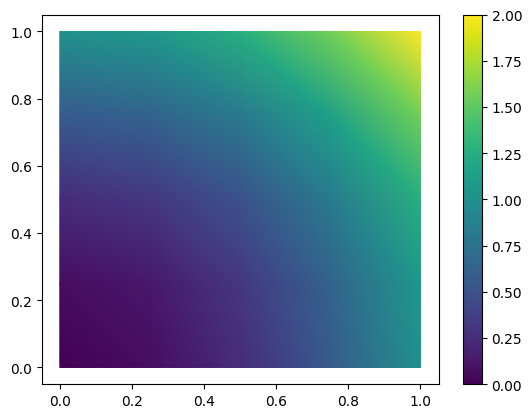

In [9]:
x, y = SpatialCoordinate(omega)
w = w.interpolate(x ** 2 + y ** 2) # since the function is in CG2 we get an exact answer (returns a `Function`)
plot_function(w)

We can obtain the interpolant of w in the CG1 function space by calling `interpolate` on w directly

[0.   0.25 0.25 0.5  1.   1.   1.25 1.25 2.  ]


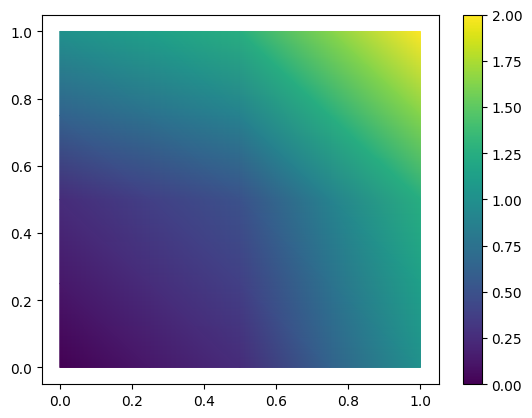

In [10]:
w_interpolated = assemble(interpolate(w, Argument(P1CG.dual(), 0)))
w_interpolated_vec = w_interpolated.dat.data[:]
print(w_interpolated_vec)
plot_function(w_interpolated)

We next compute the error in the interpolation.

The first method uses Firedrake's built-in `errornorm` function returns the $L^2$ error i.e., $||w - w_\text{interpolated}||$

The second method involves computing the $L^2$ inner product of $(w - w_\text{interpolated})$ with itself which gives the square of the $L^2$ norm $||w - w_\text{interpolated}||^2$.

In [38]:
# Compute the L^2 error of the interpolation
error = errornorm(w, w_interpolated, norm_type="L2")
print(error)

error_ = assemble(inner(w - w_interpolated, w - w_interpolated) * dx)
print(error_)

assert abs(error_ - error**2) < 1e-12


0.08740073734751255
0.0076388888888888765


Another equivalent way of interpolating w into CG1 is to multiply its basis coefficients (in the source space) with the interpolation matrix constructed earlier

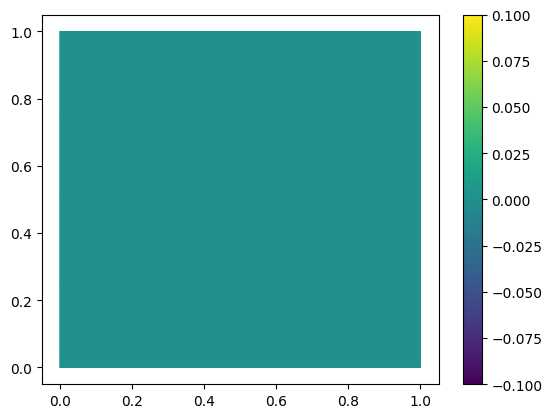

In [11]:
w_vec = w.dat.data[:] # get the basis coefficients in P2CG (returns an np array)

v = Function(P1CG) # create a function in the target space
v_vec = v.dat.data[:] # get the basis coefficients
plot_function(v) # confirm that v is initialised as the 0 field

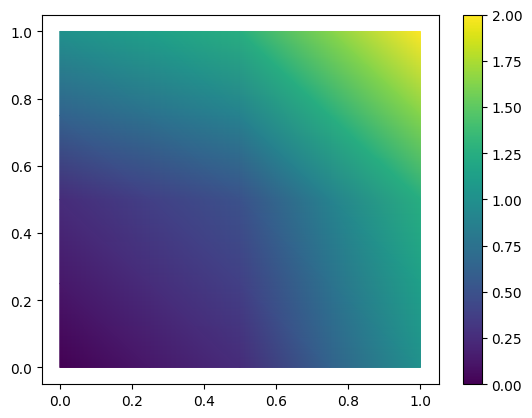

In [12]:
# Convert the structure storing the basis coefficients of w and u to PETSc vectors
w_petsc_vec = PETSc.Vec().createWithArray(w_vec, comm=PETSc.COMM_SELF)
v_petsc_vec = PETSc.Vec().createWithArray(v_vec, comm=PETSc.COMM_SELF)

# Perform the matrix multplication and store the result in v_petsc_vec
I_petsc.mult(w_petsc_vec, v_petsc_vec)

# Plot the function v
plot_function(v)

Observation: It seems like `v_petsc_vec` maintains a ref to v whose data (basis coef) get updated after the matrix multiplication